In [1]:
import pandas as pd 
import numpy as np

In [2]:
df=pd.read_csv("customer_shopping_behavior.csv")

In [3]:
df.sample(5)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
2183,2184,30,Male,Shorts,Clothing,37,Kansas,M,Maroon,Spring,4.7,No,Store Pickup,No,No,2,Cash,Monthly
259,260,32,Male,Jeans,Clothing,57,Louisiana,M,Gold,Fall,2.9,Yes,Standard,Yes,Yes,13,Debit Card,Annually
120,121,64,Male,Hat,Accessories,84,West Virginia,L,Red,Summer,4.0,Yes,Express,Yes,Yes,32,Bank Transfer,Annually
749,750,56,Male,Scarf,Accessories,71,Oklahoma,M,Olive,Winter,3.7,Yes,Standard,Yes,Yes,11,Debit Card,Quarterly
1035,1036,61,Male,Blouse,Clothing,89,Georgia,M,Brown,Fall,2.8,Yes,Express,Yes,Yes,32,Venmo,Annually


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [5]:
df.duplicated().sum()

0

In [6]:
# Summary statistics using .describe()
df.describe(include='all')

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
count,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,3863.000000,3900,3900,3900,3900,3900.000000,3900,3900
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,6,2,2,NaN,6,7
top,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,M,Olive,Spring,NaN,No,Free Shipping,No,No,NaN,PayPal,Every 3 Months
freq,NaN,NaN,2652,171,1737,NaN,96,1755,177,999,NaN,2847,675,2223,2223,NaN,677,584
mean,1950.500000,44.068462,NaN,NaN,NaN,59.764359,NaN,NaN,NaN,NaN,3.750065,NaN,NaN,NaN,NaN,25.351538,NaN,NaN
std,1125.977353,15.207589,NaN,NaN,NaN,23.685392,NaN,NaN,NaN,NaN,0.716983,NaN,NaN,NaN,NaN,14.447125,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,975.750000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,13.000000,NaN,NaN
50%,1950.500000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,25.000000,NaN,NaN
75%,2925.250000,57.000000,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,38.000000,NaN,NaN


In [7]:
# Checking if missing data or null values are present in the dataset

df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [8]:
(df['Discount Applied']==df['Promo Code Used']).all()

True

### Data Cleanning

In [9]:
df['Review Rating'].isnull().sum()

37

In [10]:
# Imputing missing values in Review Rating column with the median rating of the product category

df['Review Rating']=df.groupby('Category')['Review Rating'].transform(lambda x:x.fillna(x.median()))

In [11]:
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

In [12]:
# Renaming columns according to snake casing for better readability and documentation

df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ','_')
df = df.rename(columns={'purchase_amount_(usd)':'purchase_amount'})

In [13]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='object')

In [14]:
# create a new column age_group
labels = ['Young Adult', 'Adult', 'Middle-aged', 'Senior']
df['age_group'] = pd.qcut(df['age'], q=4, labels = labels)

In [15]:
df[['age','age_group']].head(10)

,age,age_group
0,55,Middle-aged
1,19,Young Adult
2,50,Middle-aged
3,21,Young Adult
4,45,Middle-aged
5,46,Middle-aged
6,63,Senior
7,27,Young Adult
8,26,Young Adult
9,57,Middle-aged


In [16]:
# create new column purchase_frequency_days

frequency_mapping = {
    'Fortnightly': 14,
    'Weekly': 7,
    'Monthly': 30,
    'Quarterly': 90,
    'Bi-Weekly': 14,
    'Annually': 365,
    'Every 3 Months': 90
}

df['purchase_frequency_days'] = df['frequency_of_purchases'].map(frequency_mapping)

In [17]:
df[['purchase_frequency_days','frequency_of_purchases']].head(10)

,purchase_frequency_days,frequency_of_purchases
0,14,Fortnightly
1,14,Fortnightly
2,7,Weekly
3,7,Weekly
4,365,Annually
5,7,Weekly
6,90,Quarterly
7,7,Weekly
8,365,Annually
9,90,Quarterly


In [18]:
df[['discount_applied','promo_code_used']].head(10)

,discount_applied,promo_code_used
0,Yes,Yes
1,Yes,Yes
2,Yes,Yes
3,Yes,Yes
4,Yes,Yes
5,Yes,Yes
6,Yes,Yes
7,Yes,Yes
8,Yes,Yes
9,Yes,Yes


In [19]:
(df['discount_applied'] == df['promo_code_used']).all()

True

In [20]:
# Dropping promo code used column

df = df.drop('promo_code_used', axis=1)

In [21]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases', 'age_group', 'purchase_frequency_days'],
      dtype='object')

### Connect with SQL

In [22]:
! pip install psycopg2-binary pandas sqlalchemy

Defaulting to user installation because normal site-packages is not writeable


In [23]:
! pip install psycopg2-binary

Defaulting to user installation because normal site-packages is not writeable


In [24]:
pip show psycopg2-binary

Name: psycopg2-binary
Version: 2.9.12
Summary: psycopg2 - Python-PostgreSQL Database Adapter
Home-page: https://psycopg.org/
Author: Federico Di Gregorio
Author-email: fog@initd.org
License: LGPL with exceptions
Location: C:\Users\jaman\AppData\Roaming\Python\Python312\site-packages
Requires: 
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [25]:
from sqlalchemy import create_engine

# Step 1: Connect to PostgreSQL
# Replace placeholders with your actual details
username = "postgres"      # default user
password = "Khasu300" # the password you set during installation
host = "localhost"         # if running locally
port = "5432"              # default PostgreSQL port
database = "customer behavior"    # the database you created in pgAdmin

engine = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")

# Step 2: Load DataFrame into PostgreSQL
table_name = "customer"   # choose any table name
df.to_sql(table_name, engine, if_exists="replace", index=False)

print(f"Data successfully loaded into table '{table_name}' in database '{database}'.")

Data successfully loaded into table 'customer' in database 'customer behavior'.


In [26]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases', 'age_group', 'purchase_frequency_days'],
      dtype='object')

### % by Customer by subscription status

subscription_status
No     2847
Yes    1053
Name: count, dtype: int64


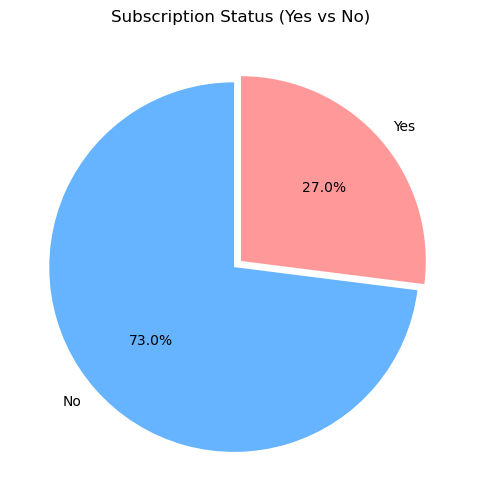

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

# count values
subscription_counts = df['subscription_status'].value_counts()

print(subscription_counts)
colors = ['#66b3ff', '#ff9999']

plt.figure(figsize=(6,6))

plt.pie(
    subscription_counts,
    labels=subscription_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    explode=(0.05, 0)  # highlight first slice
)

plt.title("Subscription Status (Yes vs No)")
plt.show()
plt.savefig('subscription_staus.png', dpi=300, bbox_inches='tight')
plt.show()

### Revnue by category

category
Clothing       104264
Accessories     74200
Footwear        36093
Outerwear       18524
Name: purchase_amount, dtype: int64


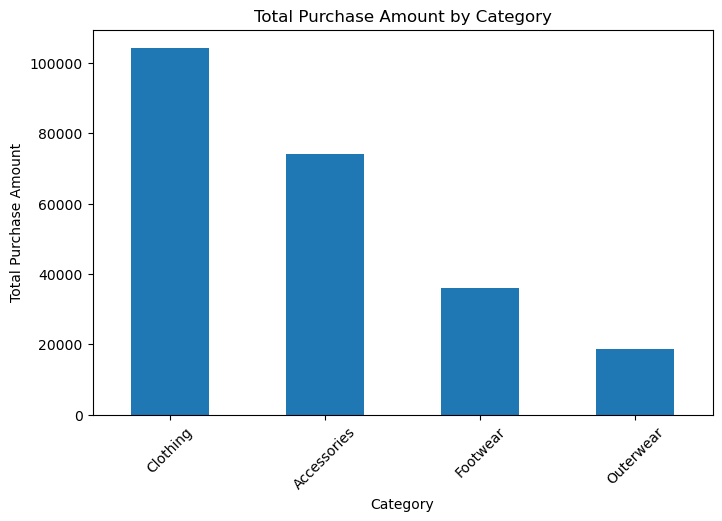

In [34]:
category_sum = df.groupby('category')['purchase_amount'].sum().sort_values(ascending=False)

print(category_sum)

plt.figure(figsize=(8,5))

category_sum.plot(kind='bar')

plt.title("Total Purchase Amount by Category")
plt.xlabel("Category")
plt.ylabel("Total Purchase Amount")

plt.xticks(rotation=45)

plt.savefig('Revnue_by_category.png', dpi=300, bbox_inches='tight')

plt.show()

category
Clothing       104264
Accessories     74200
Footwear        36093
Outerwear       18524
Name: purchase_amount, dtype: int64


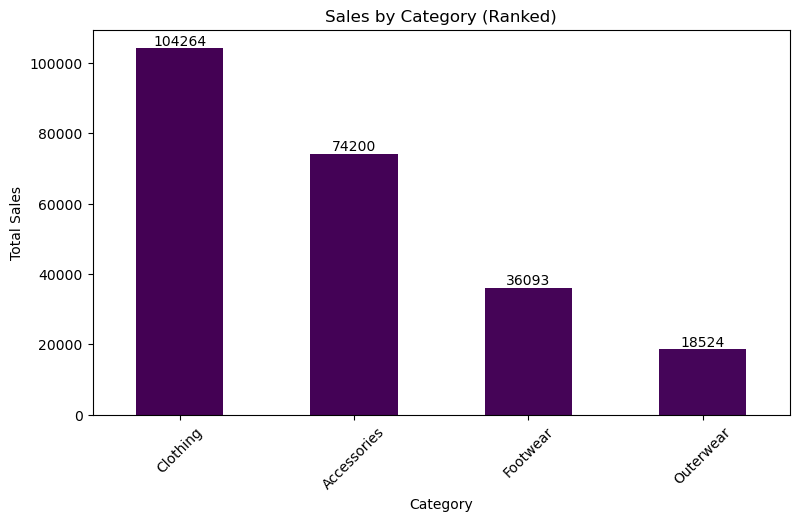

In [35]:
sales_by_category = df.groupby('category')['purchase_amount'].sum().sort_values(ascending=False)

print(sales_by_category)

plt.figure(figsize=(9,5))

colors = plt.cm.viridis(range(len(sales_by_category)))

sales_by_category.plot(kind='bar', color=colors)

plt.title("Sales by Category (Ranked)")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

# show values on top
for i, v in enumerate(sales_by_category):
    plt.text(i, v, f'{v:.0f}', ha='center', va='bottom')

plt.savefig('sales_by_category.png', dpi=300, bbox_inches='tight')

plt.show()

### Revnue BY Age Group

C:\Users\jaman\AppData\Local\Temp\ipykernel_17784\2705531881.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  revenue_by_age = df.groupby('age_group')['purchase_amount'].sum().sort_values(ascending=True)


age_group
Senior         55763
Adult          55978
Middle-aged    59197
Young Adult    62143
Name: purchase_amount, dtype: int64


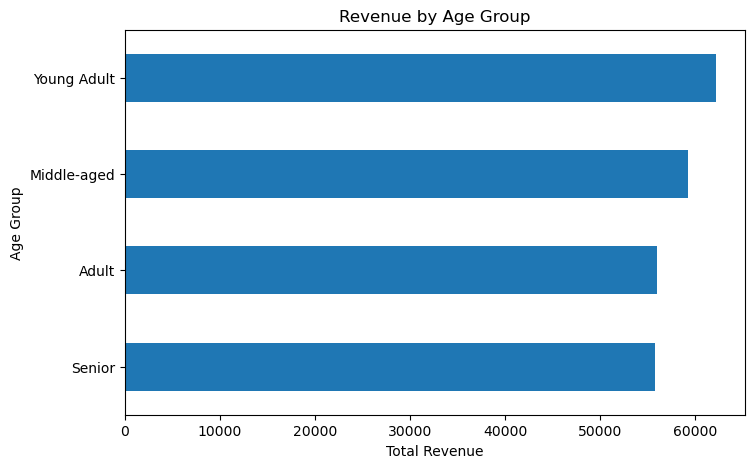

In [36]:
revenue_by_age = df.groupby('age_group')['purchase_amount'].sum().sort_values(ascending=True)
print(revenue_by_age)

plt.figure(figsize=(8,5))

revenue_by_age.plot(kind='barh')  # barh = horizontal bar chart

plt.title("Revenue by Age Group")
plt.xlabel("Total Revenue")
plt.ylabel("Age Group")
plt.savefig('Revnue_by_ageGroup.png', dpi=300, bbox_inches='tight')

plt.show()

### Sales By Age Group

C:\Users\jaman\AppData\Local\Temp\ipykernel_17784\1305441587.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sales_by_age = df.groupby('age_group')['purchase_amount'].sum().sort_values(ascending=True)


age_group
Senior         55763
Adult          55978
Middle-aged    59197
Young Adult    62143
Name: purchase_amount, dtype: int64


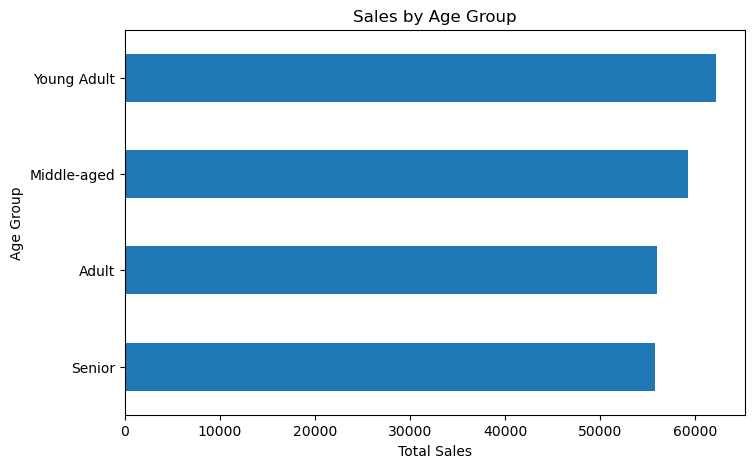

In [37]:
sales_by_age = df.groupby('age_group')['purchase_amount'].sum().sort_values(ascending=True)

print(sales_by_age)

plt.figure(figsize=(8,5))

sales_by_age.plot(kind='barh')

plt.title("Sales by Age Group")
plt.xlabel("Total Sales")
plt.ylabel("Age Group")
plt.savefig('sales_by_ageGroup.png', dpi=300, bbox_inches='tight')

plt.show()